In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

c:\ProgramData\Anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [4]:
df = pd.read_excel("CLEAN_DATA_LAST_2006.xlsx", sheet_name="Sheet1")

In [5]:
df = df.dropna(subset=["Date", "Bank_name"])
df["Bank_name"] = (
    df["Bank_name"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace('"', '', regex=False))

In [6]:
df = df[df['Measure'] == 'Активы']

In [7]:
# Группировка
df = df.sort_values("Date")
counts = df.groupby("Date")["Bank_name"].nunique()
counts

Date
2006-01-01    37
2006-03-31    37
2006-06-30    37
2006-09-30    37
2007-01-01    36
              ..
2025-01-01    21
2025-03-31    21
2025-06-30    22
2025-09-30    23
2026-01-01    23
Name: Bank_name, Length: 81, dtype: int64

In [8]:
plt.rcParams.update({
    'font.size': 14,          # базовый размер
    'axes.titlesize': 18,     # заголовок
    'axes.labelsize': 14,     # подписи осей
    'xtick.labelsize': 12,    # подписи X
    'ytick.labelsize': 12,    # подписи Y
    'legend.fontsize': 12
})

In [11]:
import matplotlib.dates as mdates

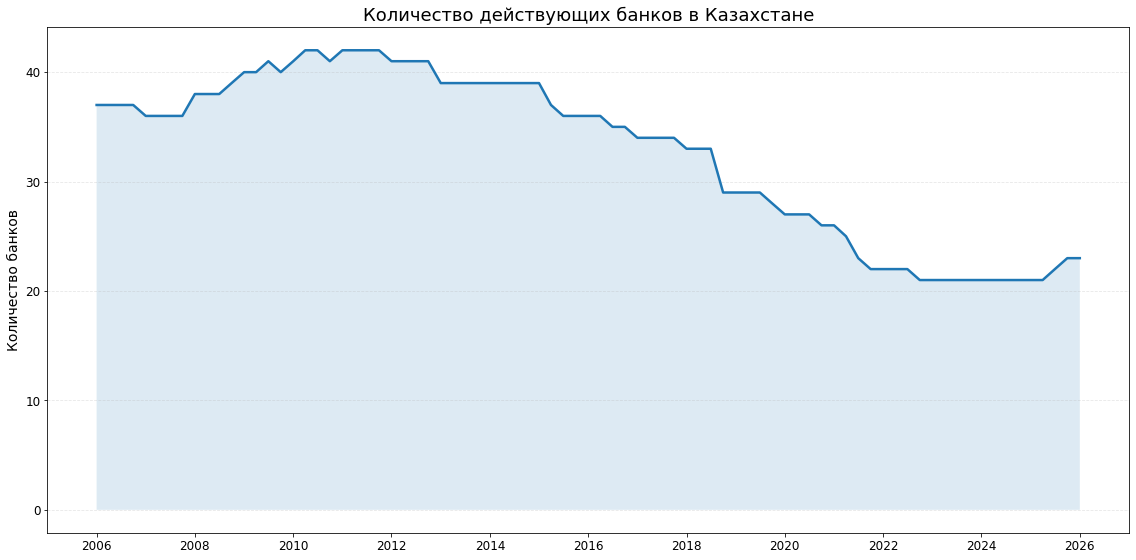

In [12]:
fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(counts.index.to_numpy(), counts.to_numpy(), linewidth=2.5)
ax.fill_between(counts.index.to_numpy(), counts.to_numpy(), alpha=0.15)

# Оформление
ax.set_ylabel('Количество банков')
ax.set_title('Количество действующих банков в Казахстане')

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('BANK_COUNT.png')
plt.show()